# The Heart Rate Spread (Homogeneity Test)

### Objective:

Analyse the 'pulse' feature in Seaborn's 'exercise' dataset. Compare individuals who are resting versus running to check if their heart rates share a homogeneous variance, and observe how Levene's Test reacts. Also, using a Boxplot - visalise the difference in their variance.

>Test Used: Levene's Test for Homogeneity of Variance

>Performed by : Raghav Katyal on 30 September 2026

In [65]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [66]:
df = sns.load_dataset('exercise')

In [67]:
df['kind'].value_counts()

kind
rest       30
walking    30
running    30
Name: count, dtype: int64

In [68]:
resting_pulse = df[df['kind']=="rest"]['pulse']
exercising_pulse = df[df['kind']=="running"]['pulse']

In [69]:
resting_pulse.std()

np.float64(5.831444686047942)

In [70]:
exercising_pulse.std()

np.float64(17.62039048714699)

In [71]:
#Running Levene's Test for Checking Homogeneity of Variance
#Expected Result : It should fail as the standard deviations of both are widely apart.
w_value,p_value = stats.levene(resting_pulse,exercising_pulse)
print(f"The W-statistic : {w_value:.3f}")
print(f"The p-value : {p_value:.3f}")

The W-statistic : 26.016
The p-value : 0.000


>Observation : A W-statistic of 26.016 and p-value of 0.00 clearly shows aggressive evidence against Homogeneity of Variance ; the data is considered not homogenous at all and structrually different.

### Visualising the difference in Variance

In [72]:
extremes = df[df['kind'].isin(['rest','running'])]

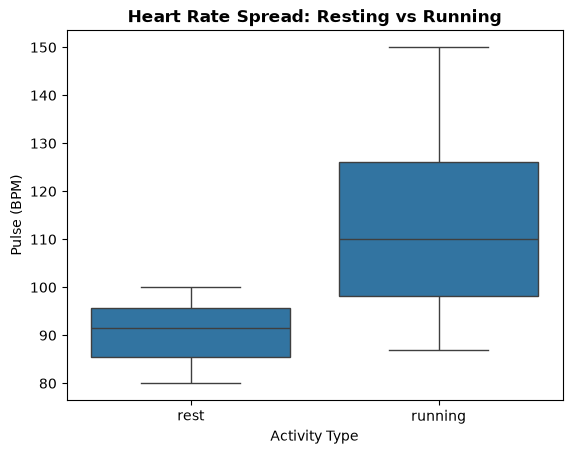

In [73]:
sns.boxplot(data=extremes,x="kind",y="pulse",order=['rest','running'])
plt.title("Heart Rate Spread: Resting vs Running",fontweight="bold")
plt.xlabel("Activity Type")
plt.ylabel("Pulse (BPM)")
plt.show()